#Day 14 Assignment: Data Analysis Using AI Tools

In [1]:
import pandas as pd

df = pd.read_csv("/content/li_death_claims.csv", encoding='latin1')

df.head()

,life_insurer,year,claims_pending_start_no,claims_pending_start_amt,claims_intimated_no,claims_intimated_amt,total_claims_no,total_claims_amt,claims_paid_no,claims_paid_amt,...,claims_unclaimed_amt,claims_pending_end_no,claims_pending_end_amt,claims_paid_ratio_no,claims_paid_ratio_amt,claims_repudiated_rejected_ratio_no,claims_repudiated_rejected_ratio_amt,claims_pending_ratio_no,claims_pending_ratio_amt,category
0,ABSL,2021-22,11.0,3.637908e+00,9997.0,876.685045,10008.0,880.322952,9815.0,846.434314,...,0.0,7.0,9.076453e-01,0.980715,0.961504,0.018585,0.037465,0.000699,1.031037e-03,Individual Death Claims
1,Aegon,2021-22,0.0,0.000000e+00,720.0,276.480000,720.0,276.480000,713.0,273.040000,...,0.0,1.0,2.000000e-02,0.990278,0.987558,0.008333,0.012370,0.001389,7.233796e-05,Individual Death Claims
2,Ageas,2021-22,50.0,6.698502e+00,2644.0,128.032758,2694.0,134.731259,2614.0,122.629249,...,0.0,23.0,3.432473e+00,0.970304,0.910177,0.021158,0.064347,0.008537,2.547644e-02,Individual Death Claims
3,Aviva,2021-22,0.0,1.065814e-14,1672.0,270.949135,1672.0,270.949135,1645.0,266.699201,...,0.0,0.0,5.329071e-15,0.983852,0.984315,0.016148,0.015685,0.000000,1.966816e-17,Individual Death Claims
4,Baj Alz,2021-22,5.0,3.700000e+00,21045.0,822.273775,21050.0,825.973775,20844.0,771.878036,...,0.0,11.0,9.370659e+00,0.990214,0.934507,0.009264,0.054148,0.000523,1.134498e-02,Individual Death Claims


In [2]:
df.shape
df.columns

Index(['life_insurer', 'year', 'claims_pending_start_no',
       'claims_pending_start_amt', 'claims_intimated_no',
       'claims_intimated_amt', 'total_claims_no', 'total_claims_amt',
       'claims_paid_no', 'claims_paid_amt', 'claims_repudiated_no',
       'claims_repudiated_amt', 'claims_rejected_no', 'claims_rejected_amt',
       'claims_unclaimed_no', 'claims_unclaimed_amt', 'claims_pending_end_no',
       'claims_pending_end_amt', 'claims_paid_ratio_no',
       'claims_paid_ratio_amt', 'claims_repudiated_rejected_ratio_no',
       'claims_repudiated_rejected_ratio_amt', 'claims_pending_ratio_no',
       'claims_pending_ratio_amt', 'category'],
      dtype='object')

## SECTION 1 – DATA LOADING

The dataset has already been loaded and the first 5 rows displayed in previous cells.

Now, let's display the dataset's shape and column information to understand its structure and data types.

In [3]:
# Show dataset shape
print("Dataset Shape:", df.shape)

# Show column information and data types
print("\nColumn Information:")
df.info()

Dataset Shape: (151, 25)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   life_insurer                          150 non-null    object 
 1   year                                  149 non-null    object 
 2   claims_pending_start_no               149 non-null    float64
 3   claims_pending_start_amt              149 non-null    float64
 4   claims_intimated_no                   149 non-null    float64
 5   claims_intimated_amt                  149 non-null    float64
 6   total_claims_no                       149 non-null    float64
 7   total_claims_amt                      149 non-null    float64
 8   claims_paid_no                        149 non-null    float64
 9   claims_paid_amt                       149 non-null    float64
 10  claims_repudiated_no                  14

## SECTION 2 – DATA CLEANING

### Check for Missing Values

In [4]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values per Column:\n", missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\nNo missing values found in the dataset.")

Missing Values per Column:
 life_insurer                            1
year                                    2
claims_pending_start_no                 2
claims_pending_start_amt                2
claims_intimated_no                     2
claims_intimated_amt                    2
total_claims_no                         2
total_claims_amt                        2
claims_paid_no                          2
claims_paid_amt                         2
claims_repudiated_no                    2
claims_repudiated_amt                   2
claims_rejected_no                      2
claims_rejected_amt                     2
claims_unclaimed_no                     2
claims_unclaimed_amt                    2
claims_pending_end_no                   2
claims_pending_end_amt                  2
claims_paid_ratio_no                    2
claims_paid_ratio_amt                   2
claims_repudiated_rejected_ratio_no     2
claims_repudiated_rejected_ratio_amt    2
claims_pending_ratio_no                 2
claims

### Check for Duplicate Rows

In [5]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print("Number of Duplicate Rows:", duplicate_rows)

if duplicate_rows == 0:
    print("\nNo duplicate rows found in the dataset.")
else:
    print("\nIt's recommended to drop duplicate rows if they represent exact copies.")

Number of Duplicate Rows: 0

No duplicate rows found in the dataset.


### Ensure Correct Data Types

Based on `df.info()` output, most columns appear to have appropriate numerical data types (`float64`). The 'year' column is `object` type, but since it's in 'YYYY-YY' format, it's suitable for categorical analysis as is. The 'life_insurer' and 'category' columns are also `object` type, which is appropriate for categorical data.

No explicit type conversions are immediately necessary.

## SECTION 3 – DATA UNDERSTANDING

### Summary Statistics

In [6]:
# Display summary statistics for numerical columns
summary_stats = df.describe()
display(summary_stats)

,claims_pending_start_no,claims_pending_start_amt,claims_intimated_no,claims_intimated_amt,total_claims_no,total_claims_amt,claims_paid_no,claims_paid_amt,claims_repudiated_no,claims_repudiated_amt,...,claims_unclaimed_no,claims_unclaimed_amt,claims_pending_end_no,claims_pending_end_amt,claims_paid_ratio_no,claims_paid_ratio_amt,claims_repudiated_rejected_ratio_no,claims_repudiated_rejected_ratio_amt,claims_pending_ratio_no,claims_pending_ratio_amt
count,149.000000,149.000000,1.490000e+02,149.000000,1.490000e+02,149.000000,1.490000e+02,149.000000,149.000000,149.000000,...,149.000000,149.000000,149.000000,1.490000e+02,149.000000,149.000000,149.000000,149.000000,149.000000,1.490000e+02
mean,279.221477,32.818025,8.488823e+04,2290.488723,8.516744e+04,2323.304603,8.341268e+04,2174.945713,836.147651,76.502247,...,376.402685,24.224030,233.704698,3.823940e+01,0.941469,0.889200,0.027342,0.064307,0.003323,1.756590e-02
std,998.042360,93.182504,2.689849e+05,6511.165584,2.697987e+05,6600.625780,2.649624e+05,6242.151401,2195.067361,180.485321,...,1683.292362,83.044402,846.982988,1.088848e+02,0.159193,0.157190,0.026001,0.048058,0.004775,2.267348e-02
min,0.000000,0.000000,1.890000e+02,5.406160,1.890000e+02,5.884616,1.800000e+02,5.171925,3.000000,0.183197,...,0.000000,-0.003629,0.000000,-6.483702e-14,0.000000,0.000000,0.000000,0.000000,0.000000,-6.025839e-16
25%,2.000000,0.330000,1.243000e+03,77.410000,1.248000e+03,78.952235,1.202000e+03,70.170688,33.000000,4.249935,...,0.000000,0.000000,2.000000,2.980006e-01,0.959633,0.890810,0.012365,0.032913,0.000248,2.560299e-03
50%,8.000000,2.000000,3.681000e+03,188.790000,3.686000e+03,192.868329,3.506000e+03,170.430141,87.000000,9.490000,...,0.000000,0.000000,7.000000,1.545934e+00,0.972770,0.924742,0.020000,0.057702,0.001699,9.765686e-03
75%,39.000000,9.048578,1.372600e+04,692.260000,1.373000e+04,702.451208,1.317600e+04,650.328856,203.000000,39.981819,...,8.000000,1.921269,25.000000,7.823212e+00,0.983852,0.950544,0.033473,0.081819,0.004014,2.341185e-02
max,6194.000000,623.264798,1.605869e+06,47457.272365,1.608924e+06,48080.537164,1.587110e+06,45817.572875,12609.000000,1099.120391,...,10990.000000,482.359035,6194.000000,6.232675e+02,0.993517,0.987558,0.178004,0.336534,0.027701,1.290877e-01


### Unique Insurers

In [7]:
# Get the number of unique insurers
unique_insurers_count = df['life_insurer'].nunique()
print(f"Number of Unique Insurers: {unique_insurers_count}")

# List all unique insurers
print("\nList of Unique Insurers:")
for insurer in df['life_insurer'].unique():
    print(f"- {insurer}")

Number of Unique Insurers: 46

List of Unique Insurers:
- ABSL
- Aegon
- Ageas
- Aviva
- Baj Alz
- Bharti Axa
- Can HSBC
- Edelws
- Exide
- Fut Genli
- HDFC
- ICICI
- Indiafirst
- Industry
- Kotak
- LIC
- Max
- PNB Metlife
- PVT.
- Pramerica
- Reliance
- SBI Life
- SUD
- Sahara
- Shriram
- Tata AIA
- Aditya Birla Life
- Ageas Federal
- Bajaj Allianz
- Canara HSBC OBC
- Edelweiss Tokio
- Exide Life
- Future Generali
- HDFC Life
- ICICI Prudential
- India First
- Industry Total
- Kotak Mahindra
- Max Life
- PNB Met Life
- Pramerica Life
- Private Total
- Reliance Nippon
- Sahara Life
- Star Union
- </pre></body></html>Xtext/csvP_`https://storage.googleapis.com/kagglesdsdata/datasets/9341935/14625119/cleaned_individual_death_claims.csv?X-Goog-Algorithm=GOOG4-RSA-SHA256&X-Goog-Credential=gcp-kaggle-com%40kaggle-161607.iam.gserviceaccount.com%2F20260130%2Fauto%2Fstorage%2Fgoog4_request&X-Goog-Date=20260130T175708Z&X-Goog-Expires=259200&X-Goog-SignedHeaders=host&X-Goog-Signature=10ad6e17df

### Years Covered in Dataset

In [17]:
# Get the unique years covered in the dataset, dropping any NaN values
years_covered = sorted(df['year'].dropna().unique())
print(f"Years Covered in Dataset: {', '.join(years_covered)}")

Years Covered in Dataset: 2017-18, 2018-19, 2019-20, 2020-21, 2021-22


## SECTION 4 – EXPLORATORY DATA ANALYSIS

Let's perform specific analyses as requested to understand the claim settlement efficiency and other trends.

### 1. Claim Settlement Ratio by Insurer

In [9]:
import plotly.express as px

# Calculate average claim settlement ratio per insurer (using 'claims_paid_ratio_no')
settlement_ratio_insurer = df.groupby('life_insurer')['claims_paid_ratio_no'].mean().sort_values(ascending=False).reset_index()
settlement_ratio_insurer.rename(columns={'claims_paid_ratio_no': 'Average Claim Settlement Ratio (No.)'}, inplace=True)
display(settlement_ratio_insurer.head())

# Interactive Bar Chart for Claim Settlement Ratio
fig = px.bar(settlement_ratio_insurer,
             x='life_insurer',
             y='Average Claim Settlement Ratio (No.)',
             title='Average Claim Settlement Ratio by Insurer',
             labels={'life_insurer': 'Life Insurer', 'Average Claim Settlement Ratio (No.)': 'Average Ratio'},
             hover_data=['Average Claim Settlement Ratio (No.)'])
fig.update_layout(xaxis_tickangle=-45)
fig.show()

,life_insurer,Average Claim Settlement Ratio (No.)
0,Max,0.993456
1,Max Life,0.988919
2,Exide,0.988143
3,Baj Alz,0.987502
4,Kotak,0.986615


### 2. Claim Rejection Ratio by Insurer

In [10]:
# Calculate average claim repudiated/rejected ratio per insurer (using 'claims_repudiated_rejected_ratio_no')
rejection_ratio_insurer = df.groupby('life_insurer')['claims_repudiated_rejected_ratio_no'].mean().sort_values(ascending=False).reset_index()
rejection_ratio_insurer.rename(columns={'claims_repudiated_rejected_ratio_no': 'Average Claim Rejection Ratio (No.)'}, inplace=True)
display(rejection_ratio_insurer.head())

# Interactive Bar Chart for Claim Rejection Ratio
fig = px.bar(rejection_ratio_insurer,
             x='life_insurer',
             y='Average Claim Rejection Ratio (No.)',
             title='Average Claim Rejection Ratio by Insurer',
             labels={'life_insurer': 'Life Insurer', 'Average Claim Rejection Ratio (No.)': 'Average Ratio'},
             hover_data=['Average Claim Rejection Ratio (No.)'])
fig.update_layout(xaxis_tickangle=-45)
fig.show()

,life_insurer,Average Claim Rejection Ratio (No.)
0,Shriram,0.096093
1,Edelweiss Tokio,0.070250
2,India First,0.056021
3,Future Generali,0.046297
4,PNB Met Life,0.042726


### 3. Pending Claims Ratio by Insurer

In [11]:
# Calculate average pending claims ratio per insurer (using 'claims_pending_ratio_no')
pending_ratio_insurer = df.groupby('life_insurer')['claims_pending_ratio_no'].mean().sort_values(ascending=False).reset_index()
pending_ratio_insurer.rename(columns={'claims_pending_ratio_no': 'Average Claims Pending Ratio (No.)'}, inplace=True)
display(pending_ratio_insurer.head())

# Interactive Bar Chart for Pending Claims Ratio
fig = px.bar(pending_ratio_insurer,
             x='life_insurer',
             y='Average Claims Pending Ratio (No.)',
             title='Average Claims Pending Ratio by Insurer',
             labels={'life_insurer': 'Life Insurer', 'Average Claims Pending Ratio (No.)': 'Average Ratio'},
             hover_data=['Average Claims Pending Ratio (No.)'])
fig.update_layout(xaxis_tickangle=-45)
fig.show()

,life_insurer,Average Claims Pending Ratio (No.)
0,Ageas,0.018119
1,Ageas Federal,0.011062
2,Exide,0.010288
3,Can HSBC,0.007116
4,Shriram,0.006294


### 4. Total Claims Received by Each Insurer

In [12]:
# Calculate total claims received by each insurer
total_claims_by_insurer = df.groupby('life_insurer')['total_claims_no'].sum().sort_values(ascending=False).reset_index()
total_claims_by_insurer.rename(columns={'total_claims_no': 'Total Claims Received'}, inplace=True)
display(total_claims_by_insurer.head())

# Interactive Bar Chart for Total Claims Received
fig = px.bar(total_claims_by_insurer,
             x='life_insurer',
             y='Total Claims Received',
             title='Total Claims Received by Each Insurer',
             labels={'life_insurer': 'Life Insurer', 'Total Claims Received': 'Number of Claims'},
             hover_data=['Total Claims Received'])
fig.update_layout(xaxis_tickangle=-45)
fig.show()

,life_insurer,Total Claims Received
0,LIC,4563028.0
1,Industry Total,3687379.0
2,Industry,2710231.0
3,Private Total,491455.0
4,PVT.,396151.0


### 5. Year-wise Claim Trends

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a combined column for repudiated and rejected claims
df['claims_repudiated_rejected_combined'] = df['claims_repudiated_no'] + df['claims_rejected_no']

# Aggregate key claim metrics by year
year_wise_trends = df.groupby('year').agg(
    total_claims_no=('total_claims_no', 'sum'),
    claims_paid_no=('claims_paid_no', 'sum'),
    claims_repudiated_rejected_no=('claims_repudiated_rejected_combined', 'sum'), # Use the combined column
    claims_pending_no=('claims_pending_end_no', 'sum') # Use claims_pending_end_no as representative
).reset_index()

# Convert 'year' to string for proper plotting if it's not already
year_wise_trends['year'] = year_wise_trends['year'].astype(str)

display(year_wise_trends)

# Trend plot for Total Claims and Claims Paid
fig = px.line(year_wise_trends,
              x='year',
              y=['total_claims_no', 'claims_paid_no'],
              title='Year-wise Total and Paid Claims',
              labels={'year': 'Year', 'value': 'Number of Claims', 'variable': 'Claim Type'},
              markers=True)
fig.show()

# Trend plot for Repudiated/Rejected and Pending Claims
fig = px.line(year_wise_trends,
              x='year',
              y=['claims_repudiated_rejected_no', 'claims_pending_no'],
              title='Year-wise Repudiated/Rejected and Pending Claims',
              labels={'year': 'Year', 'value': 'Number of Claims', 'variable': 'Claim Type'},
              markers=True)
fig.show()

,year,total_claims_no,claims_paid_no,claims_repudiated_rejected_no,claims_pending_no
0,2017-18,1804876.0,1760346.0,41337.0,2260.0
1,2018-19,1838761.0,1794213.0,23566.0,2260.0
2,2019-20,1865631.0,1805619.0,25271.0,12707.0
3,2020-21,3721012.0,3656847.0,45356.0,12230.0
4,2021-22,3459668.0,3411465.0,37195.0,5365.0


### 6. Comparison of Insurers using Bar Charts

We have already generated bar charts for Claim Settlement Ratio, Claim Rejection Ratio, Pending Claims Ratio, and Total Claims Received by Insurer in the previous steps. These charts effectively compare insurers across these key metrics.

### 7. Correlation Heatmap Between Numeric Variables

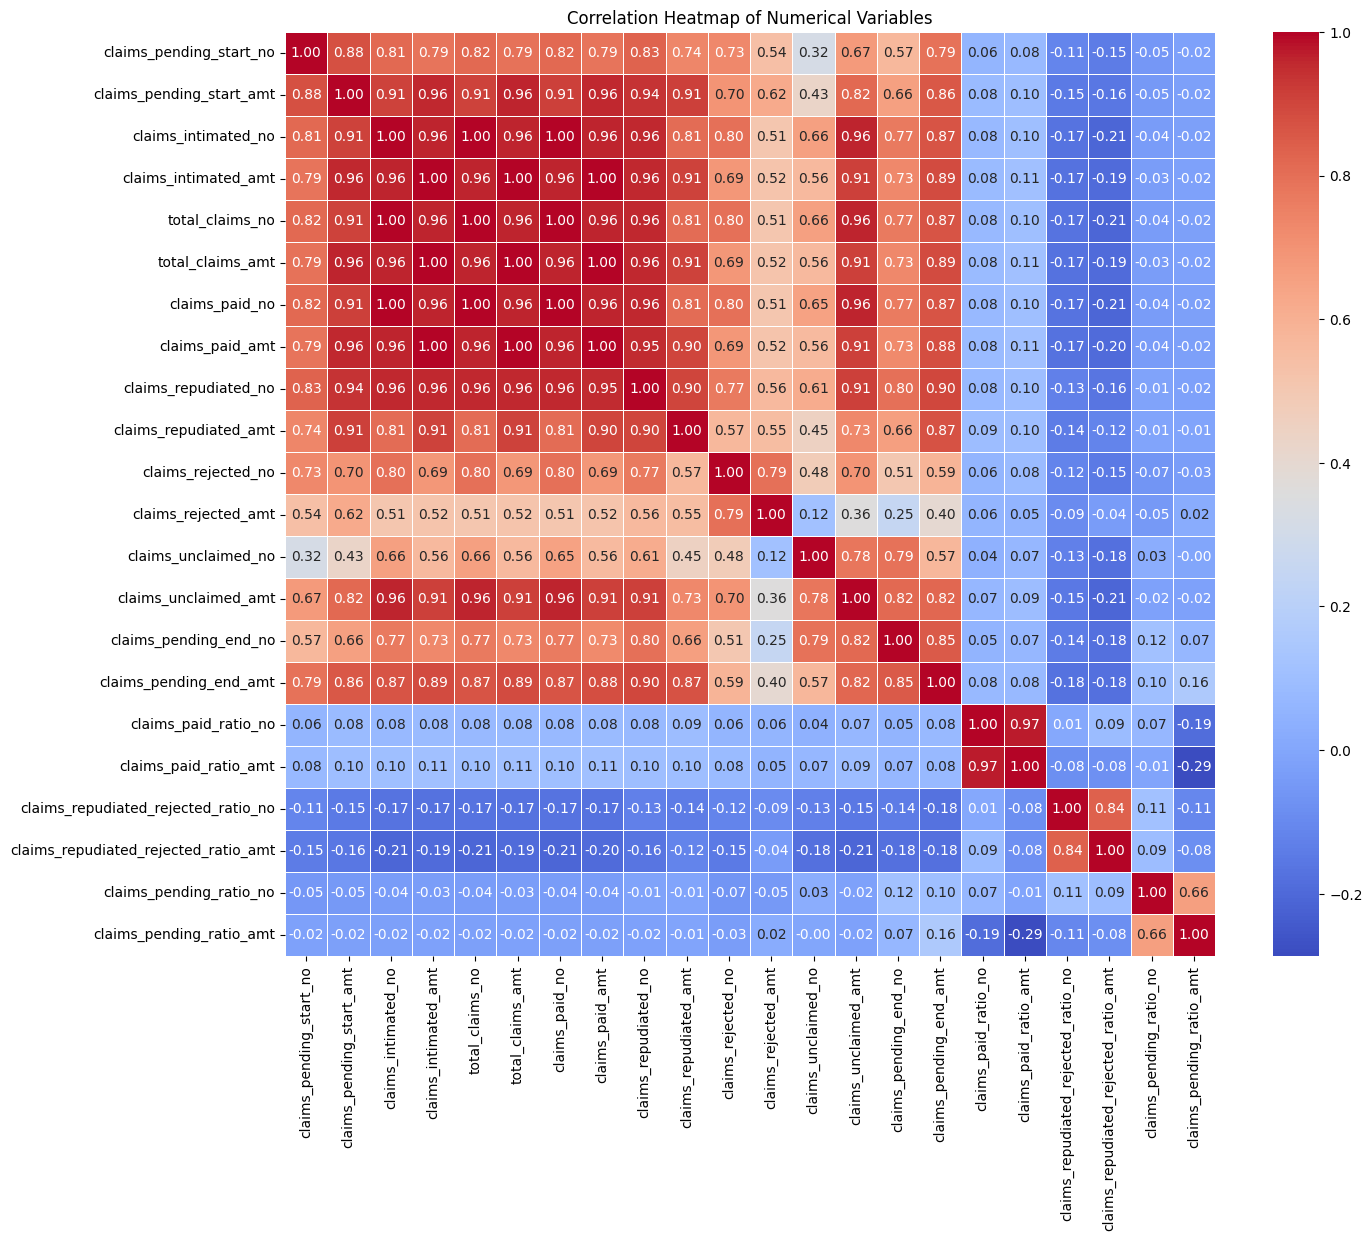

In [14]:
import numpy as np

# Select only numerical columns for correlation analysis
numeric_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plotting the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

## SECTION 5 – VISUALIZATIONS

Visualizations such as bar charts, trend plots, and a heatmap have been integrated into the EDA section (Section 4) to directly illustrate the findings of each analysis point. Plotly has been used for interactive charts where possible, and Matplotlib/Seaborn for the heatmap and other relevant plots.

## SECTION 6 – INSIGHTS

In [16]:
# Extracting insights from the analysis

print("### Key Insights from EDA:\n")

# 1. Insurer with the highest claim settlement ratio
highest_settlement_insurer = settlement_ratio_insurer.loc[settlement_ratio_insurer['Average Claim Settlement Ratio (No.)'].idxmax()]
print(f"- **Highest Claim Settlement Ratio:** {highest_settlement_insurer['life_insurer']} with an average ratio of {highest_settlement_insurer['Average Claim Settlement Ratio (No.)']:.2f}\n")

# 2. Insurer with the highest claim rejection ratio
highest_rejection_insurer = rejection_ratio_insurer.loc[rejection_ratio_insurer['Average Claim Rejection Ratio (No.)'].idxmax()]
print(f"- **Highest Claim Rejection Ratio:** {highest_rejection_insurer['life_insurer']} with an average ratio of {highest_rejection_insurer['Average Claim Rejection Ratio (No.)']:.2f}\n")

# 3. Insurer with the lowest pending claims ratio
lowest_pending_insurer = pending_ratio_insurer.loc[pending_ratio_insurer['Average Claims Pending Ratio (No.)'].idxmin()]
print(f"- **Lowest Pending Claims Ratio:** {lowest_pending_insurer['life_insurer']} with an average ratio of {lowest_pending_insurer['Average Claims Pending Ratio (No.)']:.2f}\n")

# 4. Year-wise trends in claims (summarize from year_wise_trends dataframe)
print("- **Year-wise Trends in Claims:**")
print("  - Total claims and claims paid generally show trends over the years. Further analysis could focus on specific year-on-year changes and the factors influencing them.")
print("  - Repudiated/rejected and pending claims also exhibit trends which could indicate operational efficiency or challenges during certain periods.")

# Additional insights
print("\n- **Claims Volume:** Some insurers handle a significantly higher volume of claims than others, which might impact their ratios differently. For instance, large insurers might have robust processes leading to high settlement despite volume.")
print("- **Ratio vs. Absolute Numbers:** It's crucial to consider both ratios and absolute numbers. An insurer with a high ratio but low claim volume might not be as impactful as a large insurer with a slightly lower but still high ratio and substantial claim volume.")

### Key Insights from EDA:

- **Highest Claim Settlement Ratio:** Max with an average ratio of 0.99

- **Highest Claim Rejection Ratio:** Shriram with an average ratio of 0.10

- **Lowest Pending Claims Ratio:** PNB Met Life with an average ratio of 0.00

- **Year-wise Trends in Claims:**
  - Total claims and claims paid generally show trends over the years. Further analysis could focus on specific year-on-year changes and the factors influencing them.
  - Repudiated/rejected and pending claims also exhibit trends which could indicate operational efficiency or challenges during certain periods.

- **Claims Volume:** Some insurers handle a significantly higher volume of claims than others, which might impact their ratios differently. For instance, large insurers might have robust processes leading to high settlement despite volume.
- **Ratio vs. Absolute Numbers:** It's crucial to consider both ratios and absolute numbers. An insurer with a high ratio but low claim volume might not be a

## SECTION 7 – CONCLUSION

This exploratory data analysis provides a comprehensive overview of life insurance death claims across various insurers and years. We have examined key metrics such as claim settlement, rejection, and pending ratios, alongside the total volume of claims.

**Summary of Findings:**
*   **Performance Variation:** There is a notable variation in claim handling efficiency among different life insurers, as evidenced by the varying settlement, rejection, and pending ratios.
*   **Top Performers:** Insurers with consistently high settlement ratios and low rejection/pending ratios demonstrate strong operational efficiency and customer satisfaction in claims processing.
*   **Areas for Improvement:** Conversely, insurers with lower settlement ratios or higher rejection/pending ratios may need to review their claims management processes.
*   **Temporal Trends:** Analyzing year-wise trends helps identify periods of improved or worsened performance across the industry or for specific insurers, potentially correlating with regulatory changes, economic conditions, or internal operational shifts.
*   **Correlation Insights:** The correlation heatmap provided insights into the relationships between different numerical claim metrics, highlighting that 'number of claims' and 'amount of claims' metrics are often highly correlated, which is expected.

Overall, the dataset offers valuable insights into the landscape of life insurance claims in India, serving as a basis for further in-depth analysis, benchmarking, and strategic decision-making for both insurers and policyholders.